In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (roc_auc_score, roc_curve, 
                             classification_report, confusion_matrix,
                             precision_recall_curve, average_precision_score)
from scipy.stats import ks_2samp

BASE_DIR = Path().resolve().parent

In [2]:

data = pd.read_csv(BASE_DIR / "data" / "processed" / "processed_train.csv")

import re
data.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in data.columns]

X = data.drop(['TARGET', 'SK_ID_CURR'], axis=1)
y = data['TARGET']

best_model = joblib.load(BASE_DIR / "models" / "best_model.pkl")


results_df = pd.read_csv(BASE_DIR / "models" / "model_results.csv")

print("Data and model loaded successfully")
print(f"Best model: {results_df.iloc[0]['Model']}")
print(f"Best ROC-AUC: {results_df.iloc[0]['ROC-AUC']:.4f}")

Data and model loaded successfully
Best model: XGBoost
Best ROC-AUC: 0.7522


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_test = pd.DataFrame(X_test, columns=X.columns)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

print(f"Test set shape: {X_test.shape}")
print(f"Default rate in test set: {y_test.mean()*100:.2f}%")

Test set shape: (61503, 193)
Default rate in test set: 8.07%


In [4]:
auc = roc_auc_score(y_test, y_pred_proba)
gini = 2 * auc - 1

defaulters_scores = y_pred_proba[y_test == 1]
non_defaulters_scores = y_pred_proba[y_test == 0]
ks_stat, _ = ks_2samp(defaulters_scores, non_defaulters_scores)
avg_precision = average_precision_score(y_test, y_pred_proba)

print(f"ROC-AUC  : {auc:.4f}  {'✓' if auc > 0.75 else '✗'}")
print(f"Gini     : {gini:.4f}  {'✓' if gini > 0.50 else '✗'}")
print(f"KS Stat  : {ks_stat:.4f}  {'✓' if ks_stat > 0.30 else '✗'}")
print(f"Avg Prec : {avg_precision:.4f}")

ROC-AUC  : 0.7522  ✓
Gini     : 0.5044  ✓
KS Stat  : 0.3733  ✓
Avg Prec : 0.2334


### ROC Curve

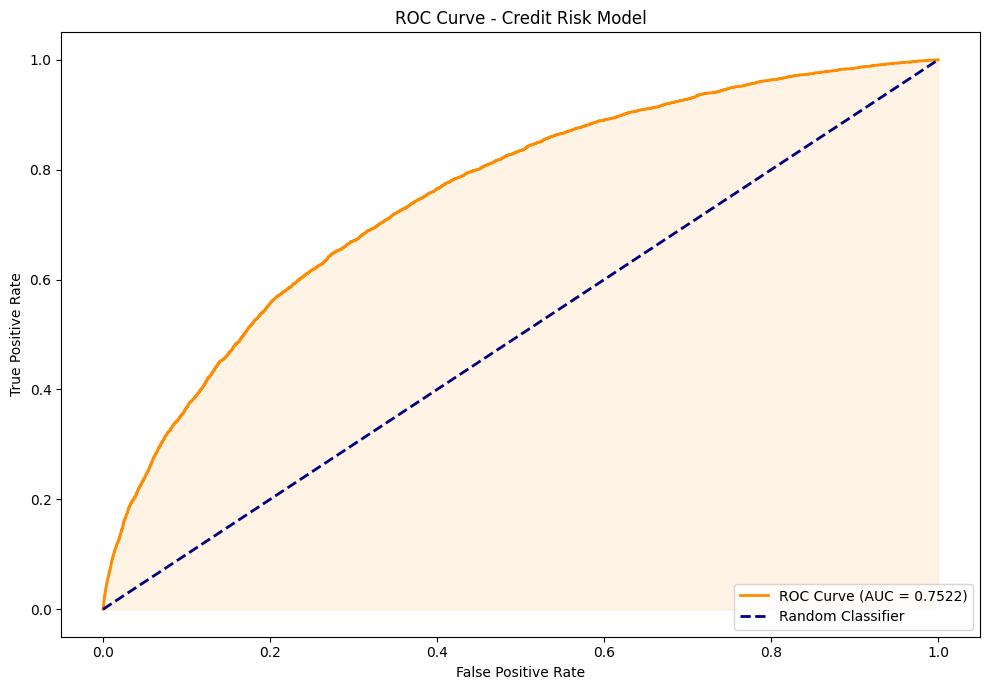

In [5]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Credit Risk Model')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../reports/figures/roc_curve_final.png')
plt.show()

Confusion Matrix

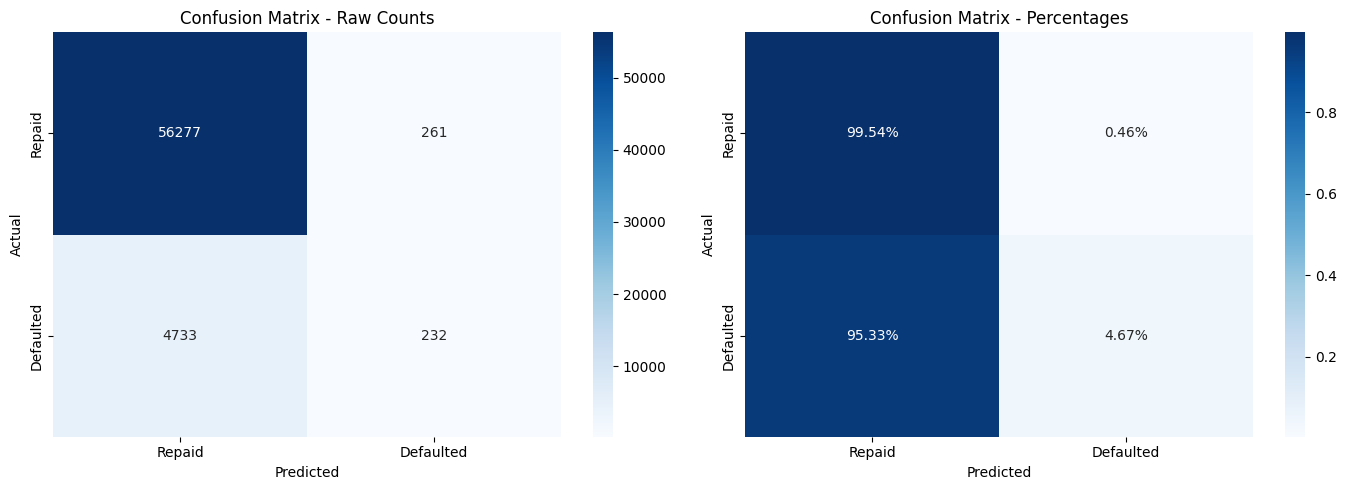

              precision    recall  f1-score   support

      Repaid       0.92      1.00      0.96     56538
   Defaulted       0.47      0.05      0.09      4965

    accuracy                           0.92     61503
   macro avg       0.70      0.52      0.52     61503
weighted avg       0.89      0.92      0.89     61503



In [6]:
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Repaid', 'Defaulted'],
            yticklabels=['Repaid', 'Defaulted'])
axes[0].set_title('Confusion Matrix - Raw Counts')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Percentages
sns.heatmap(cm_pct, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Repaid', 'Defaulted'],
            yticklabels=['Repaid', 'Defaulted'])
axes[1].set_title('Confusion Matrix - Percentages')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix_final.png')
plt.show()

print(classification_report(y_test, y_pred, 
                            target_names=['Repaid', 'Defaulted']))

KS statistic Plot 

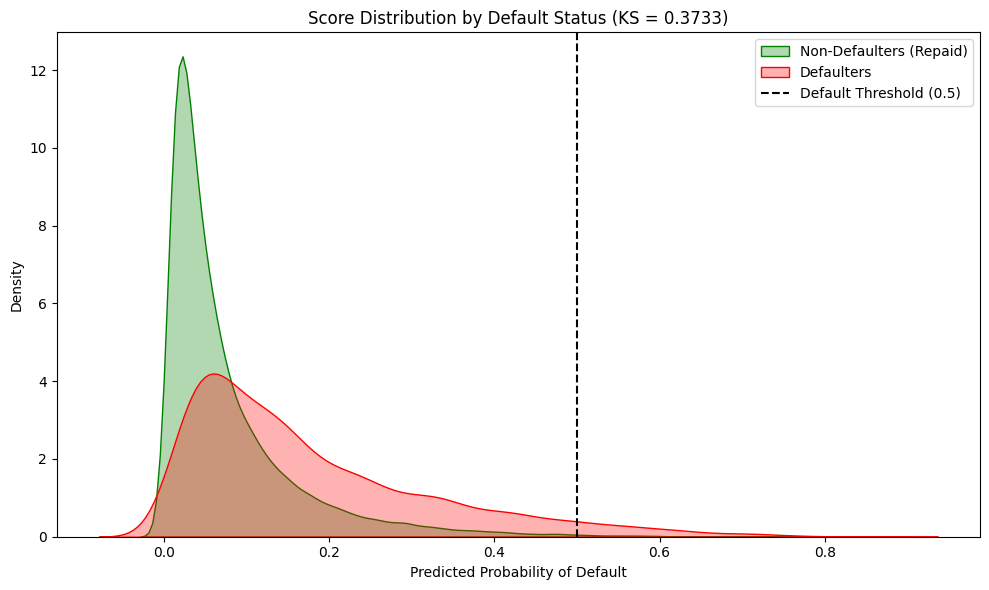

In [7]:
plt.figure(figsize=(10, 6))


sns.kdeplot(non_defaulters_scores, label='Non-Defaulters (Repaid)', 
            color='green', fill=True, alpha=0.3)
sns.kdeplot(defaulters_scores, label='Defaulters', 
            color='red', fill=True, alpha=0.3)

plt.axvline(x=0.5, color='black', linestyle='--', label='Default Threshold (0.5)')
plt.title(f'Score Distribution by Default Status (KS = {ks_stat:.4f})')
plt.xlabel('Predicted Probability of Default')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/ks_statistic_plot.png')
plt.show()

### Precision - Recall Curve 

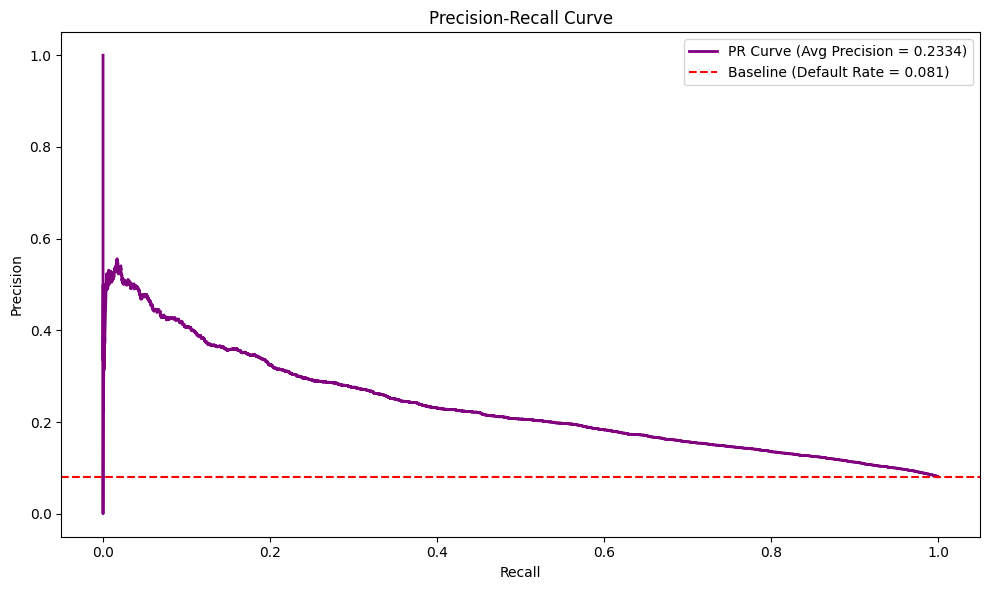

In [8]:
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(10, 6))
plt.plot(recall, precision, color='purple', lw=2,
         label=f'PR Curve (Avg Precision = {avg_precision:.4f})')
plt.axhline(y=y_test.mean(), color='red', linestyle='--', 
            label=f'Baseline (Default Rate = {y_test.mean():.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/precision_recall_curve.png')
plt.show()

### Threshold Analysis

In [9]:
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]
threshold_results = []

for thresh in thresholds_to_test:
    y_pred_thresh = (y_pred_proba >= thresh).astype(int)
    cm_thresh = confusion_matrix(y_test, y_pred_thresh)
    
    tn, fp, fn, tp = cm_thresh.ravel()
    precision_val = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0
    approval_rate = (y_pred_thresh == 0).mean()
    
    threshold_results.append({
        'Threshold': thresh,
        'Precision': round(precision_val, 4),
        'Recall': round(recall_val, 4),
        'Approval Rate': round(approval_rate, 4),
        'Defaults Caught': tp,
        'Defaults Missed': fn
    })

threshold_df = pd.DataFrame(threshold_results)
print(threshold_df.to_string(index=False))

 Threshold  Precision  Recall  Approval Rate  Defaults Caught  Defaults Missed
       0.3     0.3375  0.1913         0.9542              950             4015
       0.4     0.4075  0.1007         0.9800              500             4465
       0.5     0.4706  0.0467         0.9920              232             4733
       0.6     0.5399  0.0177         0.9973               88             4877
       0.7     0.5000  0.0054         0.9991               27             4938


### Score Distribution By Risk Band 

           Total_Borrowers  Actual_Defaults  Default_Rate
risk_band                                                
Very Low             55096             3300        0.0599
Low                   5180             1165        0.2249
Medium                1064              412        0.3872
High                   156               86        0.5513
Very High                7                2        0.2857


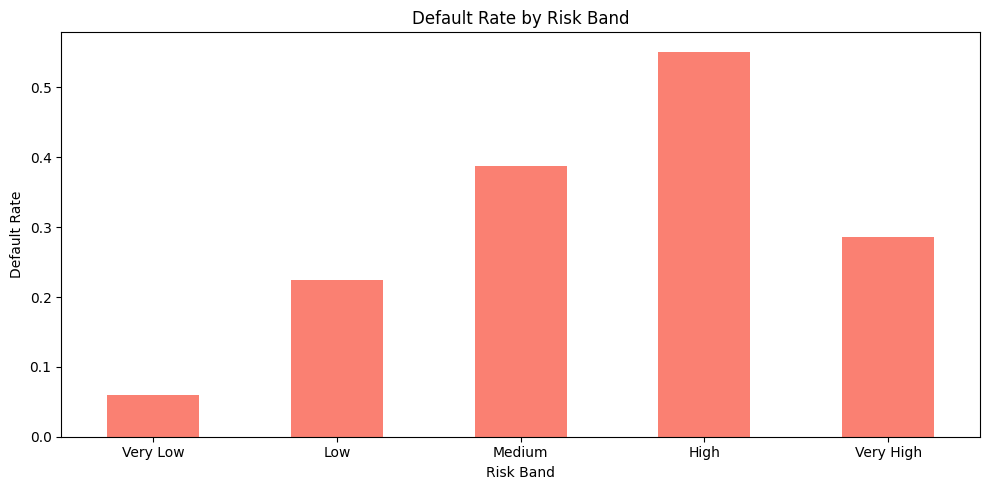

In [10]:
test_results = pd.DataFrame({
    'actual': y_test.values,
    'predicted_proba': y_pred_proba
})

test_results['risk_band'] = pd.cut(
    test_results['predicted_proba'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

risk_analysis = test_results.groupby('risk_band').agg(
    Total_Borrowers = ('actual', 'count'),
    Actual_Defaults = ('actual', 'sum'),
    Default_Rate = ('actual', 'mean')
).round(4)

print(risk_analysis)

plt.figure(figsize=(10, 5))
risk_analysis['Default_Rate'].plot(kind='bar', color='salmon')
plt.title('Default Rate by Risk Band')
plt.xlabel('Risk Band')
plt.ylabel('Default Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/default_rate_by_risk_band.png')
plt.show()